# SPRM Energy Distribution And Landscape Analysis

This notebook inspects the `SPRM_data` energy tables, reports duplicate `(global_id, left_open, right_open)` cells, collapses duplicates by mean energy, and compares closed-state energy distributions plus average nucleosome-opening energy landscapes across datasets.

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SPRM_ROOT = PROJECT_ROOT / "SPRM_data"
EXPECTED_OPENING_STATES = 105

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 80)

print(f"Project root: {PROJECT_ROOT}")
print(f"SPRM root:    {SPRM_ROOT}")

Project root: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis
SPRM root:    /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/SPRM_data


## 1. Loading Helpers

In [2]:
def discover_datasets(sprm_root: Path = SPRM_ROOT) -> list[Path]:
    """Return dataset folders that contain both required SPRM TSV files."""
    if not sprm_root.exists():
        raise FileNotFoundError(f"SPRM root not found: {sprm_root}")

    dataset_dirs = []
    for dataset_dir in sorted(p for p in sprm_root.iterdir() if p.is_dir()):
        if (dataset_dir / "energies.tsv").exists() and (dataset_dir / "id_lookup.tsv").exists():
            dataset_dirs.append(dataset_dir)
    return dataset_dirs


def load_dataset(dataset_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load one dataset's energy table and ID lookup table."""
    energies = pd.read_csv(
        dataset_dir / "energies.tsv",
        sep="\t",
        dtype={"global_id": "int64", "left_open": "int16", "right_open": "int16", "dF_total": "float64"},
    )
    id_lookup = pd.read_csv(dataset_dir / "id_lookup.tsv", sep="\t")
    energies["dataset"] = dataset_dir.name
    id_lookup["dataset"] = dataset_dir.name
    return energies, id_lookup


def duplicate_cell_report(energies: pd.DataFrame) -> pd.DataFrame:
    """Report repeated measurements for the same dataset/id/opening-state cell."""
    keys = ["dataset", "global_id", "left_open", "right_open"]
    report = (
        energies.groupby(keys, observed=True)
        .agg(
            n_rows=("dF_total", "size"),
            mean_dF_total=("dF_total", "mean"),
            min_dF_total=("dF_total", "min"),
            max_dF_total=("dF_total", "max"),
            std_dF_total=("dF_total", "std"),
        )
        .reset_index()
    )
    return report.loc[report["n_rows"] > 1].sort_values(
        ["dataset", "global_id", "left_open", "right_open"]
    )


def duplicate_id_summary(energies: pd.DataFrame) -> pd.DataFrame:
    """Summarize repeated full-state blocks per dataset and ID."""
    per_id = (
        energies.groupby(["dataset", "global_id"], observed=True)
        .agg(
            n_rows=("dF_total", "size"),
            n_opening_states=("left_open", "size"),
            n_unique_cells=("right_open", lambda s: np.nan),
        )
        .reset_index()
    )

    unique_cells = (
        energies[["dataset", "global_id", "left_open", "right_open"]]
        .drop_duplicates()
        .groupby(["dataset", "global_id"], observed=True)
        .size()
        .rename("n_unique_cells")
        .reset_index()
    )
    per_id = per_id.drop(columns="n_unique_cells").merge(unique_cells, on=["dataset", "global_id"])
    per_id["repeat_factor"] = per_id["n_rows"] / per_id["n_unique_cells"]
    return per_id.loc[per_id["n_rows"] > per_id["n_unique_cells"]].sort_values(
        ["dataset", "repeat_factor", "global_id"], ascending=[True, False, True]
    )


def collapse_duplicate_cells(energies: pd.DataFrame) -> pd.DataFrame:
    """Collapse repeated dataset/id/opening-state cells by mean dF_total."""
    keys = ["dataset", "global_id", "left_open", "right_open"]
    collapsed = energies.groupby(keys, observed=True, as_index=False).agg(dF_total=("dF_total", "mean"))
    return collapsed


def validation_summary(energies: pd.DataFrame, id_lookup: pd.DataFrame) -> pd.DataFrame:
    """Dataset-level structure checks after duplicate collapse."""
    rows = []
    for dataset, df in energies.groupby("dataset", observed=True):
        ids = id_lookup.loc[id_lookup["dataset"] == dataset, "global_id"].nunique()
        per_id_cells = df.groupby("global_id", observed=True).size()
        closed_rows = df.query("left_open == 0 and right_open == 0").shape[0]
        rows.append(
            {
                "dataset": dataset,
                "id_lookup_ids": ids,
                "energy_ids": df["global_id"].nunique(),
                "energy_rows": len(df),
                "closed_rows": closed_rows,
                "min_cells_per_id": int(per_id_cells.min()),
                "max_cells_per_id": int(per_id_cells.max()),
                "all_ids_have_105_states": bool((per_id_cells == EXPECTED_OPENING_STATES).all()),
                "left_open_range": f"{df['left_open'].min()}..{df['left_open'].max()}",
                "right_open_range": f"{df['right_open'].min()}..{df['right_open'].max()}",
            }
        )
    return pd.DataFrame(rows)


def closed_state_table(energies: pd.DataFrame) -> pd.DataFrame:
    return energies.loc[(energies["left_open"] == 0) & (energies["right_open"] == 0)].copy()


def add_relative_energy(energies: pd.DataFrame) -> pd.DataFrame:
    """Add dF_relative = dF_total - per-ID closed-state dF_total."""
    closed = closed_state_table(energies)[["dataset", "global_id", "dF_total"]].rename(
        columns={"dF_total": "closed_dF_total"}
    )
    out = energies.merge(closed, on=["dataset", "global_id"], how="left", validate="many_to_one")
    missing = out["closed_dF_total"].isna().sum()
    if missing:
        raise ValueError(f"Missing closed-state energy for {missing} rows")
    out["dF_relative"] = out["dF_total"] - out["closed_dF_total"]
    return out


def landscape_mean(energies: pd.DataFrame, value_col: str) -> pd.DataFrame:
    return (
        energies.groupby(["dataset", "left_open", "right_open"], observed=True)[value_col]
        .mean()
        .rename("mean_energy")
        .reset_index()
    )

## 2. Load SPRM Data

In [3]:
dataset_dirs = discover_datasets()
print(f"Found {len(dataset_dirs)} datasets")
for dataset_dir in dataset_dirs:
    print(" -", dataset_dir.name)

loaded = [load_dataset(dataset_dir) for dataset_dir in dataset_dirs]
raw_energies = pd.concat([item[0] for item in loaded], ignore_index=True)
id_lookup = pd.concat([item[1] for item in loaded], ignore_index=True)

print(f"Raw energy rows: {len(raw_energies):,}")
print(f"ID lookup rows:  {len(id_lookup):,}")
raw_energies.head()

Found 8 datasets
 - ctrl01_random_genome_safe
 - ctrl02_random_genome_gcmatched
 - ctrl03_som_gcmatched
 - ctrl04_bound_prom_evicted
 - ctrl05_unbound_prom_random
 - ret_broad_nuc
 - ret_intermediate_nuc
 - ret_single_nuc
Raw energy rows: 15,766,485
ID lookup rows:  148,522


,global_id,left_open,right_open,dF_total,dataset
0,0,0,0,1.739542,ctrl01_random_genome_safe
1,0,0,1,2.774421,ctrl01_random_genome_safe
2,0,0,2,8.227709,ctrl01_random_genome_safe
3,0,0,3,5.420778,ctrl01_random_genome_safe
4,0,0,4,8.040023,ctrl01_random_genome_safe


## 3. Duplicate Diagnostics Before Averaging

In [4]:
duplicate_cells = duplicate_cell_report(raw_energies)
duplicate_ids = duplicate_id_summary(raw_energies)

duplicate_overview = (
    duplicate_cells.groupby("dataset", observed=True)
    .agg(
        duplicated_cells=("global_id", "size"),
        duplicated_ids=("global_id", "nunique"),
        max_cell_repeats=("n_rows", "max"),
        mean_cell_repeats=("n_rows", "mean"),
    )
    .reset_index()
)

display(duplicate_overview)
display(duplicate_ids.head(30))
display(duplicate_cells.head(30))

,dataset,duplicated_cells,duplicated_ids,max_cell_repeats,mean_cell_repeats
0,ctrl02_random_genome_gcmatched,140385,1337,5,2.21466
1,ctrl03_som_gcmatched,945,9,2,2.00000
2,ctrl05_unbound_prom_random,210,2,2,2.00000


,dataset,global_id,n_rows,n_opening_states,n_unique_cells,repeat_factor
31063,ctrl02_random_genome_gcmatched,11063,525,525,105,5.0
30151,ctrl02_random_genome_gcmatched,10151,420,420,105,4.0
22534,ctrl02_random_genome_gcmatched,2534,315,315,105,3.0
30461,ctrl02_random_genome_gcmatched,10461,315,315,105,3.0
30467,ctrl02_random_genome_gcmatched,10467,315,315,105,3.0
30469,ctrl02_random_genome_gcmatched,10469,315,315,105,3.0
30471,ctrl02_random_genome_gcmatched,10471,315,315,105,3.0
30472,ctrl02_random_genome_gcmatched,10472,315,315,105,3.0
30475,ctrl02_random_genome_gcmatched,10475,315,315,105,3.0
30477,ctrl02_random_genome_gcmatched,10477,315,315,105,3.0


,dataset,global_id,left_open,right_open,n_rows,mean_dF_total,min_dF_total,max_dF_total,std_dF_total
2118900,ctrl02_random_genome_gcmatched,180,0,0,2,-20.672487,-20.672487,-20.672487,0.0
2118901,ctrl02_random_genome_gcmatched,180,0,1,2,-13.927914,-13.927914,-13.927914,0.0
2118902,ctrl02_random_genome_gcmatched,180,0,2,2,-5.599297,-5.599297,-5.599297,0.0
2118903,ctrl02_random_genome_gcmatched,180,0,3,2,-7.204720,-7.204720,-7.204720,0.0
2118904,ctrl02_random_genome_gcmatched,180,0,4,2,-4.451730,-4.451730,-4.451730,0.0
2118905,ctrl02_random_genome_gcmatched,180,0,5,2,-5.340922,-5.340922,-5.340922,0.0
2118906,ctrl02_random_genome_gcmatched,180,0,6,2,-6.239898,-6.239898,-6.239898,0.0
2118907,ctrl02_random_genome_gcmatched,180,0,7,2,-4.930339,-4.930339,-4.930339,0.0
2118908,ctrl02_random_genome_gcmatched,180,0,8,2,-4.930442,-4.930442,-4.930442,0.0
2118909,ctrl02_random_genome_gcmatched,180,0,9,2,-2.031705,-2.031705,-2.031705,0.0


The tables above are intentionally shown before duplicate averaging. Downstream analysis uses one value per `(dataset, global_id, left_open, right_open)`, with repeated cells collapsed by mean `dF_total`.

In [5]:
energies = collapse_duplicate_cells(raw_energies)
energies = add_relative_energy(energies)

print(f"Rows before duplicate collapse: {len(raw_energies):,}")
print(f"Rows after duplicate collapse:  {len(energies):,}")

validation = validation_summary(energies, id_lookup)
display(validation)

assert len(dataset_dirs) == 8, f"Expected 8 datasets, found {len(dataset_dirs)}"
assert validation["all_ids_have_105_states"].all(), "At least one dataset has IDs without 105 opening states"
assert (validation["closed_rows"] == validation["energy_ids"]).all(), "Closed-state rows do not match energy IDs"

Rows before duplicate collapse: 15,766,485
Rows after duplicate collapse:  15,594,810


,dataset,id_lookup_ids,energy_ids,energy_rows,closed_rows,min_cells_per_id,max_cells_per_id,all_ids_have_105_states,left_open_range,right_open_range
0,ctrl01_random_genome_safe,20000,20000,2100000,20000,105,105,True,0..13,0..13
1,ctrl02_random_genome_gcmatched,11402,11402,1197210,11402,105,105,True,0..13,0..13
2,ctrl03_som_gcmatched,49342,49342,5180910,49342,105,105,True,0..13,0..13
3,ctrl04_bound_prom_evicted,20000,20000,2100000,20000,105,105,True,0..13,0..13
4,ctrl05_unbound_prom_random,20000,20000,2100000,20000,105,105,True,0..13,0..13
5,ret_broad_nuc,6922,6922,726810,6922,105,105,True,0..13,0..13
6,ret_intermediate_nuc,6339,6339,665595,6339,105,105,True,0..13,0..13
7,ret_single_nuc,14517,14517,1524285,14517,105,105,True,0..13,0..13


## 4. Closed-State Energy Distributions

,dataset,count,mean,median,std,min,max
0,ctrl01_random_genome_safe,20000,1.405419,3.485024,11.300955,-58.082745,35.840400
1,ctrl02_random_genome_gcmatched,11402,-27.715716,-28.045966,7.784334,-64.241350,12.618101
2,ctrl03_som_gcmatched,49342,-31.771304,-31.800959,9.211341,-78.429535,11.851269
3,ctrl04_bound_prom_evicted,20000,-10.150051,-9.694725,13.033116,-55.443222,24.229855
4,ctrl05_unbound_prom_random,20000,-7.388965,-7.331724,12.005853,-67.766340,23.924809
5,ret_broad_nuc,6922,-34.188983,-34.253944,7.261874,-59.407180,-5.741594
6,ret_intermediate_nuc,6339,-32.030815,-32.190850,7.845089,-60.380180,10.226812
7,ret_single_nuc,14517,-29.393810,-29.605220,9.004237,-62.599255,10.191382


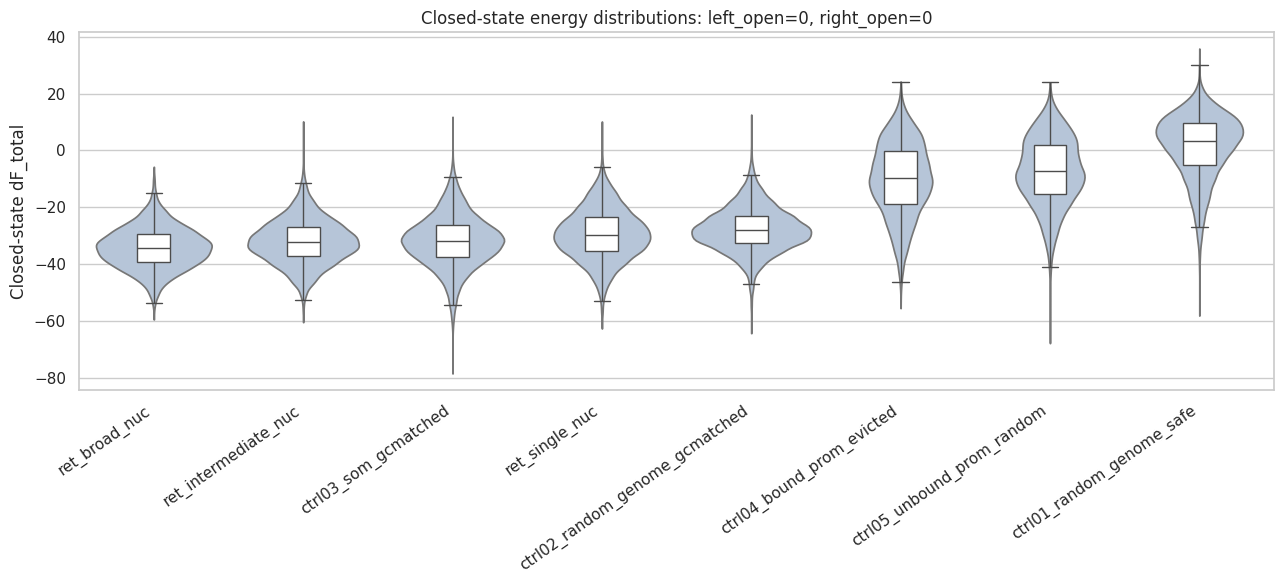

In [6]:
closed = closed_state_table(energies)

closed_summary = (
    closed.groupby("dataset", observed=True)["dF_total"]
    .agg(count="size", mean="mean", median="median", std="std", min="min", max="max")
    .reset_index()
)
display(closed_summary)

plt.figure(figsize=(13, 6))
order = closed_summary.sort_values("mean")["dataset"]
sns.violinplot(data=closed, x="dataset", y="dF_total", order=order, inner=None, color="lightsteelblue", cut=0)
sns.boxplot(
    data=closed,
    x="dataset",
    y="dF_total",
    order=order,
    width=0.22,
    showfliers=False,
    boxprops={"facecolor": "white", "zorder": 2},
)
plt.xticks(rotation=35, ha="right")
plt.xlabel("")
plt.ylabel("Closed-state dF_total")
plt.title("Closed-state energy distributions: left_open=0, right_open=0")
plt.tight_layout()
plt.show()

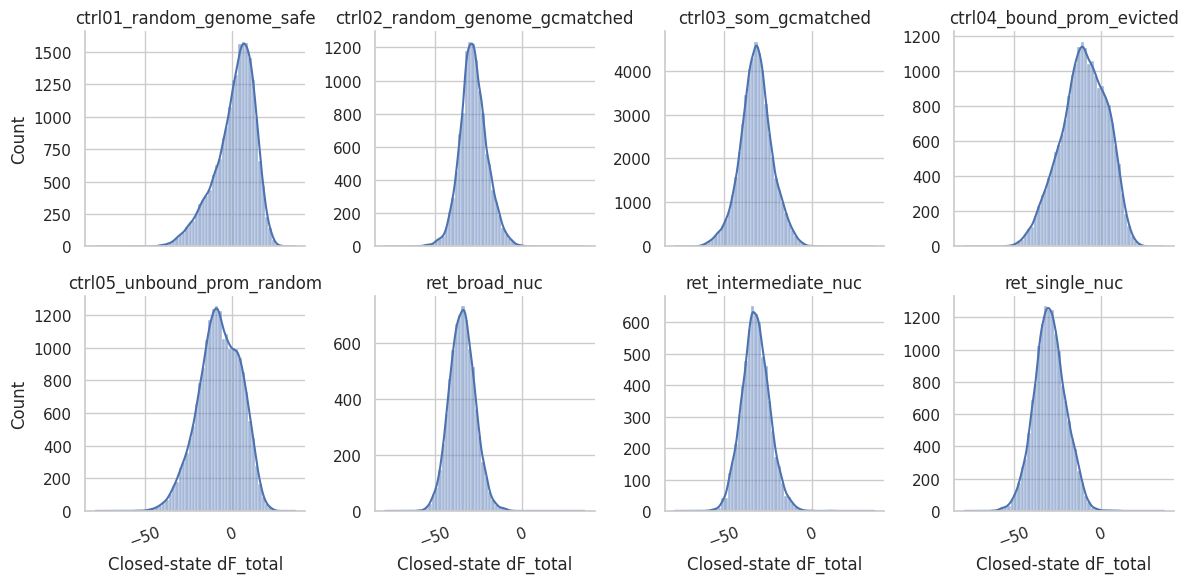

In [7]:
g = sns.displot(
    data=closed,
    x="dF_total",
    col="dataset",
    col_wrap=4,
    kind="hist",
    kde=True,
    bins=60,
    facet_kws={"sharex": True, "sharey": False},
    height=3.0,
)
g.set_axis_labels("Closed-state dF_total", "Count")
g.set_titles("{col_name}")
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 5. Average Energy Landscape Maps

In [8]:
def plot_landscape_grid(landscape: pd.DataFrame, title: str, cbar_label: str, cmap: str = "vlag"):
    datasets = sorted(landscape["dataset"].unique())
    n_cols = 4
    n_rows = math.ceil(len(datasets) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 3.6 * n_rows), constrained_layout=True)
    axes = np.asarray(axes).reshape(-1)

    vmin = landscape["mean_energy"].min()
    vmax = landscape["mean_energy"].max()
    if vmin < 0 < vmax:
        limit = max(abs(vmin), abs(vmax))
        vmin, vmax = -limit, limit

    mappable = None
    for ax, dataset in zip(axes, datasets):
        df = landscape.loc[landscape["dataset"] == dataset]
        matrix = df.pivot(index="left_open", columns="right_open", values="mean_energy").sort_index(ascending=True)
        matrix = matrix.reindex(index=range(14), columns=range(14))
        mask = np.fromfunction(lambda i, j: i + j > 13, matrix.shape, dtype=int)
        sns.heatmap(
            matrix,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            mask=mask,
            square=True,
            cbar=False,
            linewidths=0.25,
            linecolor="white",
        )
        ax.set_title(dataset, fontsize=10)
        ax.set_xlabel("right_open")
        ax.set_ylabel("left_open")
        mappable = ax.collections[0]

    for ax in axes[len(datasets):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=15)
    if mappable is not None:
        fig.colorbar(mappable, ax=axes.tolist(), shrink=0.75, label=cbar_label)
    plt.show()


absolute_landscape = landscape_mean(energies, "dF_total")
relative_landscape = landscape_mean(energies, "dF_relative")

display(absolute_landscape.head())
display(relative_landscape.head())

,dataset,left_open,right_open,mean_energy
0,ctrl01_random_genome_safe,0,0,1.405419
1,ctrl01_random_genome_safe,0,1,2.656734
2,ctrl01_random_genome_safe,0,2,7.244487
3,ctrl01_random_genome_safe,0,3,5.093133
4,ctrl01_random_genome_safe,0,4,7.910302


,dataset,left_open,right_open,mean_energy
0,ctrl01_random_genome_safe,0,0,0.000000
1,ctrl01_random_genome_safe,0,1,1.251315
2,ctrl01_random_genome_safe,0,2,5.839068
3,ctrl01_random_genome_safe,0,3,3.687714
4,ctrl01_random_genome_safe,0,4,6.504883


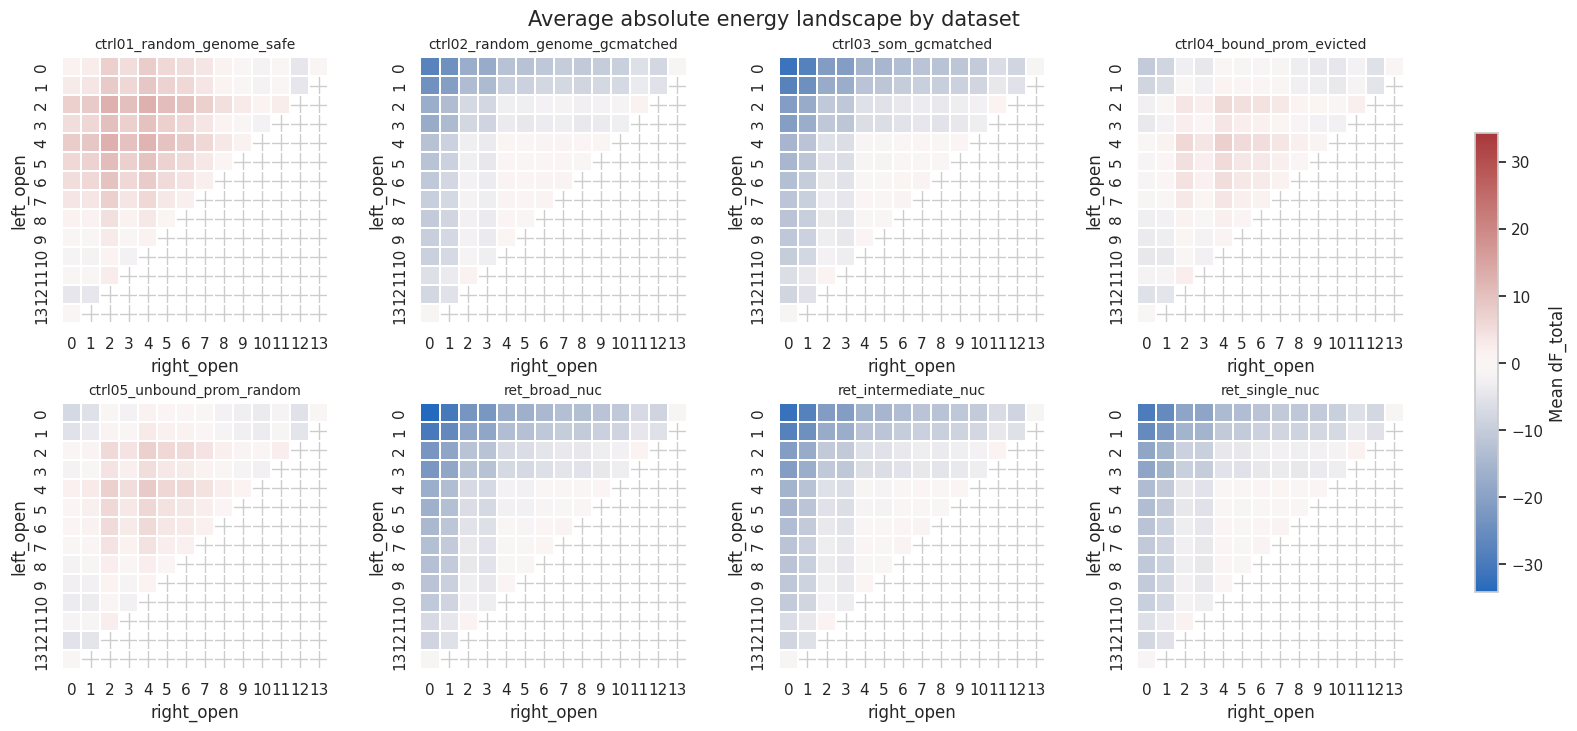

In [9]:
plot_landscape_grid(
    absolute_landscape,
    title="Average absolute energy landscape by dataset",
    cbar_label="Mean dF_total",
    cmap="vlag",
)

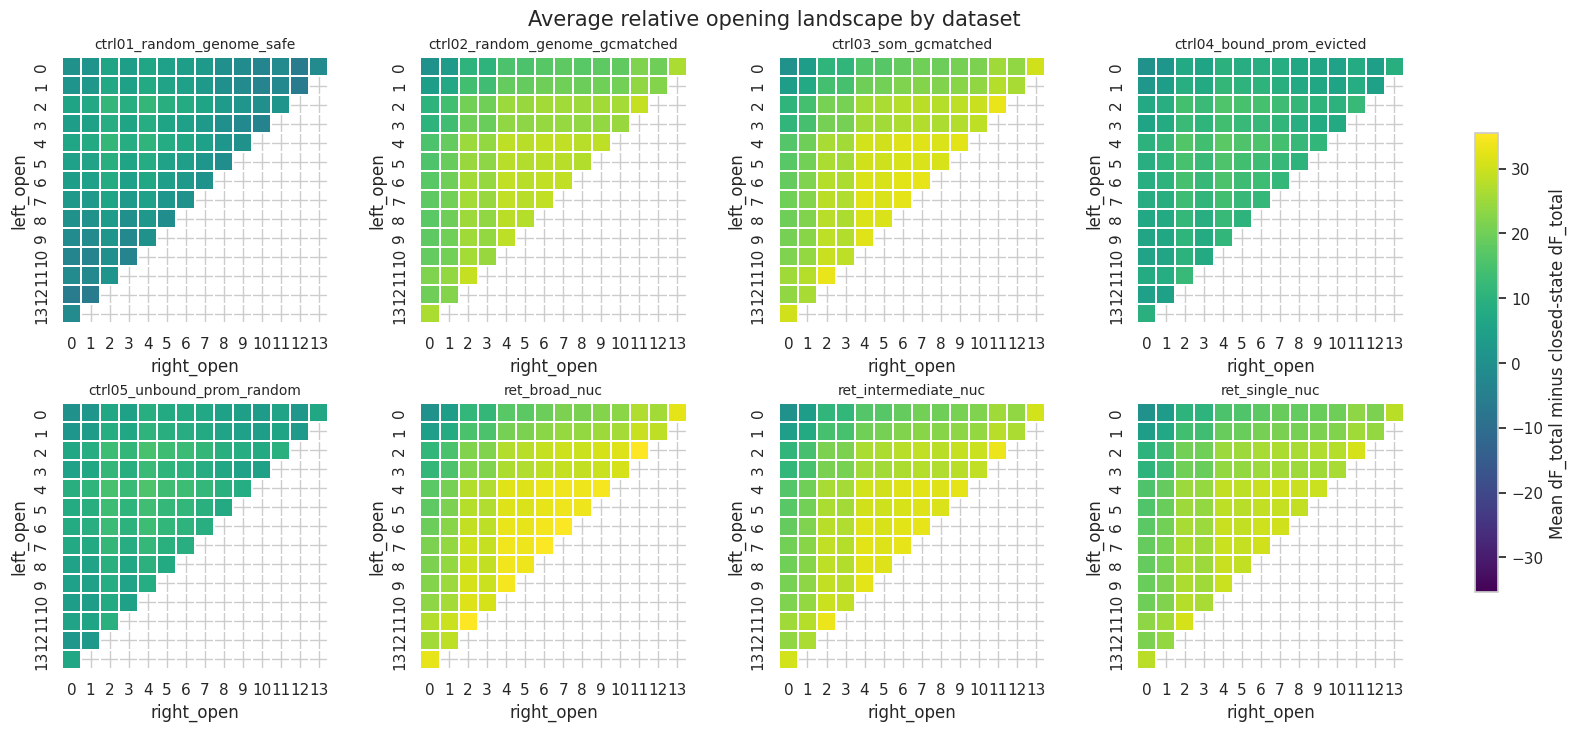

In [10]:
plot_landscape_grid(
    relative_landscape,
    title="Average relative opening landscape by dataset",
    cbar_label="Mean dF_total minus closed-state dF_total",
    cmap="viridis",
)

## 6. Exportable Tables

In [11]:
tables = {
    "validation": validation,
    "duplicate_overview": duplicate_overview,
    "duplicate_ids": duplicate_ids,
    "closed_summary": closed_summary,
    "absolute_landscape": absolute_landscape,
    "relative_landscape": relative_landscape,
}

for name, table in tables.items():
    print(f"{name}: {table.shape[0]:,} rows x {table.shape[1]:,} columns")

validation: 8 rows x 10 columns
duplicate_overview: 3 rows x 5 columns
duplicate_ids: 1,348 rows x 6 columns
closed_summary: 8 rows x 7 columns
absolute_landscape: 840 rows x 4 columns
relative_landscape: 840 rows x 4 columns
